# Marketing Funnel Analysis

In [1]:
# Load required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("Marketing_Funnel.csv")

In [3]:
# Display the first 5 rows of the dataset
print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Shape (Rows, Columns):", df.shape)
print("\nDataset Info:")
df.info()

First 5 rows of the dataset:


,user_id,session_id,date,month,channel,campaign_type,device,user_type,region,visited_website,viewed_product,added_to_cart,checkout_started,purchase_completed,discount_applied,order_value,revenue
0,221958,1,8/16/2025,2025-08,Organic,New Launch,Mobile,New,Metro,True,False,False,False,False,False,499.00,0.000
1,771155,2,12/16/2025,2025-12,Organic,Influencer,Mobile,New,Non-Metro,True,True,True,False,False,False,499.00,0.000
2,231932,3,7/17/2025,2025-07,Organic,Influencer,Mobile,New,Non-Metro,True,True,False,False,False,False,499.00,0.000
3,465838,4,7/4/2025,2025-07,Paid Ads,Discount,Mobile,Returning,Metro,True,True,True,True,True,True,2000.95,1800.855
4,359178,5,8/10/2025,2025-08,Paid Ads,Influencer,Mobile,Returning,Non-Metro,True,False,False,False,False,False,499.00,0.000



Dataset Shape (Rows, Columns): (120000, 17)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   user_id             120000 non-null  int64  
 1   session_id          120000 non-null  int64  
 2   date                120000 non-null  str    
 3   month               120000 non-null  str    
 4   channel             120000 non-null  str    
 5   campaign_type       120000 non-null  str    
 6   device              120000 non-null  str    
 7   user_type           120000 non-null  str    
 8   region              120000 non-null  str    
 9   visited_website     120000 non-null  bool   
 10  viewed_product      120000 non-null  bool   
 11  added_to_cart       120000 non-null  bool   
 12  checkout_started    120000 non-null  bool   
 13  purchase_completed  120000 non-null  bool   
 14  discount_applied    120000 non-null

In [4]:
# Check for missing values and duplicate records to ensure data integrity
print("Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

duplicate_count = df.duplicated().sum()
print(f"\nTotal duplicate rows found: {duplicate_count}")

# Drop duplicates if any exist to clean the dataframe for analysis
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed successfully.")
else:
    print("No duplicate rows found.")

Missing values per column:
Series([], dtype: int64)

Total duplicate rows found: 0
No duplicate rows found.


# Funnel Drop-Off & Conversion Analysis

In [5]:
# Define the sequential steps of the marketing funnel
funnel_steps = [
    'visited_website',
    'viewed_product',
    'added_to_cart',
    'checkout_started',
    'purchase_completed',
]

# Calculate absolute numbers for each step grouped by marketing channel
channel_funnel = df.groupby('channel')[funnel_steps].sum()
print('--- Channel Wise Funnel Absolute Numbers ---')
print(channel_funnel)

# Calculate conversion rates relative to website visits (%)
channel_conv = (
    channel_funnel.div(channel_funnel['visited_website'], axis=0) * 100
)
print('\n--- Channel Wise Conversion Rates (%) ---')
print(channel_conv.round(2))

--- Channel Wise Funnel Absolute Numbers ---
          visited_website  viewed_product  added_to_cart  checkout_started  \
channel                                                                      
Email               12092            7892           2838              1722   
Organic             35946           23327           8158              4909   
Paid Ads            53891           35011          12058              7161   
Social              18071           11640           4102              2442   

          purchase_completed  
channel                       
Email                    884  
Organic                 2448  
Paid Ads                3619  
Social                  1230  

--- Channel Wise Conversion Rates (%) ---
          visited_website  viewed_product  added_to_cart  checkout_started  \
channel                                                                      
Email               100.0           65.27          23.47             14.24   
Organic             100

# Discount Impact & Revenue Analysis

In [6]:
# Analyze the impact of discounts on sessions, total revenue, average order value, and purchases by channel
discount_analysis = (
    df.groupby(['channel', 'discount_applied'])
    .agg(
        total_sessions=('user_id', 'count'),
        total_revenue=('revenue', 'sum'),
        avg_order_value=('order_value', 'mean'),
        purchases=('purchase_completed', 'sum'),
    )
    .reset_index()
)

print('--- Discount & Revenue Analysis by Channel ---')
print(discount_analysis)

--- Discount & Revenue Analysis by Channel ---
    channel  discount_applied  total_sessions  total_revenue  avg_order_value  \
0     Email             False           11595     829687.370       553.900765   
1     Email              True             497     981612.945      2194.529276   
2   Organic             False           34604    2423055.770       553.073569   
3   Organic              True            1342    2667652.677      2208.687429   
4  Paid Ads             False           51935    3667616.780       553.640989   
5  Paid Ads              True            1956    3868530.300      2197.529141   
6    Social             False           17404    1265072.160       555.546493   
7    Social              True             667    1313371.152      2187.857991   

   purchases  
0        387  
1        497  
2       1106  
3       1342  
4       1663  
5       1956  
6        563  
7        667  


 # Overall Funnel Drop-Off Percentage Check

In [7]:
# Aggregate total counts across all users to evaluate where the biggest drop-off occurs
total_visitors = df['visited_website'].sum()
total_viewed = df['viewed_product'].sum()
total_cart = df['added_to_cart'].sum()
total_checkout = df['checkout_started'].sum()
total_purchase = df['purchase_completed'].sum()

drop_off_summary = {
    'Step': [
        'Website Visit',
        'Product View',
        'Added to Cart',
        'Checkout Started',
        'Purchase Completed',
    ],
    'Users': [
        total_visitors,
        total_viewed,
        total_cart,
        total_checkout,
        total_purchase,
    ],
}

df_drop = pd.DataFrame(drop_off_summary)
# Calculate cumulative drop-off percentage from the initial visit
df_drop['Drop-off % from Start'] = (
    (total_visitors - df_drop['Users']) / total_visitors
) * 100
print(df_drop)

                 Step   Users  Drop-off % from Start
0       Website Visit  120000               0.000000
1        Product View   77870              35.108333
2       Added to Cart   27156              77.370000
3    Checkout Started   16234              86.471667
4  Purchase Completed    8181              93.182500


# Device and User Type Performance

In [8]:
# Evaluate performance segmentation based on device type and whether the user is new or returning
device_user_analysis = (
    df.groupby(['device', 'user_type'])
    .agg(
        total_sessions=('user_id', 'count'),
        total_purchases=('purchase_completed', 'sum'),
        total_revenue=('revenue', 'sum'),
    )
    .reset_index()
)

# Calculate overall conversion rate for each segment
device_user_analysis['Conversion_Rate_%'] = (
    device_user_analysis['total_purchases']
    / device_user_analysis['total_sessions']
) * 100
print(device_user_analysis)

    device  user_type  total_sessions  total_purchases  total_revenue  \
0  Desktop        New           23219             1634    3400623.676   
1  Desktop  Returning           12775              854    1772343.309   
2   Mobile        New           54750             3764    7825178.190   
3   Mobile  Returning           29256             1929    4018453.979   

   Conversion_Rate_%  
0           7.037340  
1           6.684932  
2           6.874886  
3           6.593519  


### Chart 1: Total Revenue Generated by Marketing Channel

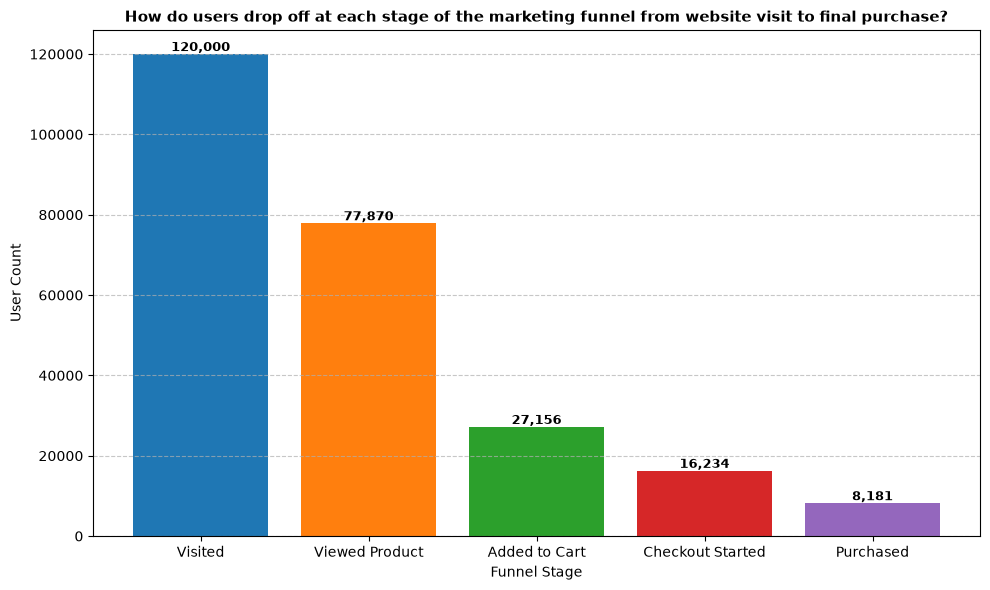

In [9]:
stages = [
    'Visited',
    'Viewed Product',
    'Added to Cart',
    'Checkout Started',
    'Purchased',
]
counts = [
    df['visited_website'].sum(),
    df['viewed_product'].sum(),
    df['added_to_cart'].sum(),
    df['checkout_started'].sum(),
    df['purchase_completed'].sum(),
]

plt.figure(figsize=(10, 6))
bars = plt.bar(
    stages,
    counts,
    color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'],
)
plt.title(
    'How do users drop off at each stage of the marketing funnel from website'
    ' visit to final purchase?',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('Funnel Stage')
plt.ylabel('User Count')

for bar in bars:
  height = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      height,
      f'{height:,}',
      ha='center',
      va='bottom',
      fontsize=9,
      fontweight='bold',
  )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Chart 2: Channel-wise Funnel Conversion Rate

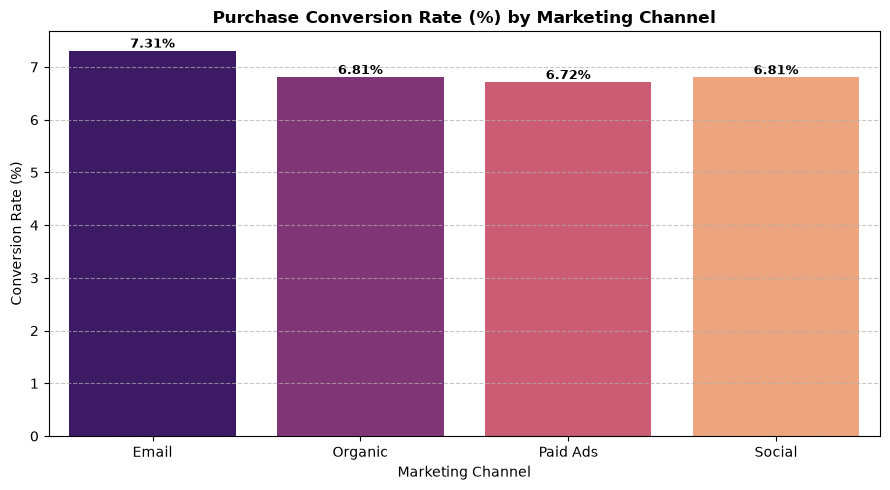

In [10]:
df_channel_conv = (
    df.groupby('channel')['purchase_completed'].sum()
    / df.groupby('channel')['visited_website'].sum()
) * 100
df_channel_conv = df_channel_conv.reset_index()
df_channel_conv.columns = ['Channel', 'Conversion_Rate']

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x='Channel',
    y='Conversion_Rate',
    data=df_channel_conv,
    hue='Channel',
    palette='magma',
    legend=False,
)
plt.title(
    'Purchase Conversion Rate (%) by Marketing Channel',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Marketing Channel')
plt.ylabel('Conversion Rate (%)')

for p in ax.patches:
  height = p.get_height()
  ax.annotate(
      f'{height:.2f}%',
      (p.get_x() + p.get_width() / 2.0, height),
      ha='center',
      va='bottom',
      fontsize=9,
      fontweight='bold',
  )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Chart 3: Overall Marketing Funnel Drop-off

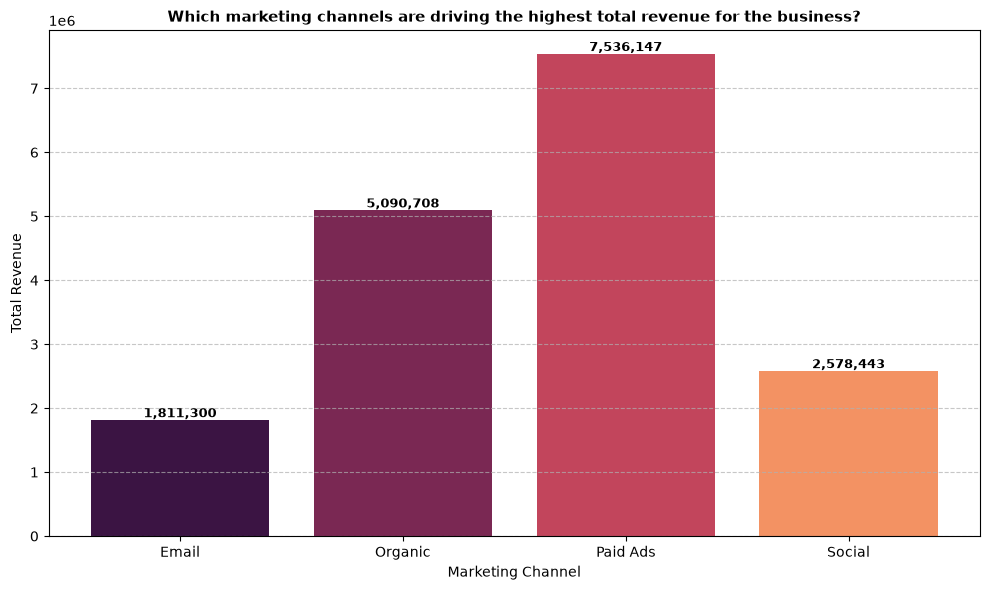

In [11]:
valid_revenue = df[df['purchase_completed'] == True].groupby('channel')['revenue'].sum()

channels = valid_revenue.index.tolist()
revenues = valid_revenue.values.tolist()

plt.figure(figsize=(10, 6))
bars = plt.bar(channels, revenues, color=['#3b1443', '#7a2853', '#c2455c', '#f39263'])
plt.title('Which marketing channels are driving the highest total revenue for the business?', fontsize=11, fontweight='bold')
plt.xlabel('Marketing Channel')
plt.ylabel('Total Revenue')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Chart 4: Purchase Completion by Device Type

device
Desktop    6.912263
Mobile     6.776897
Name: purchase_completed, dtype: float64


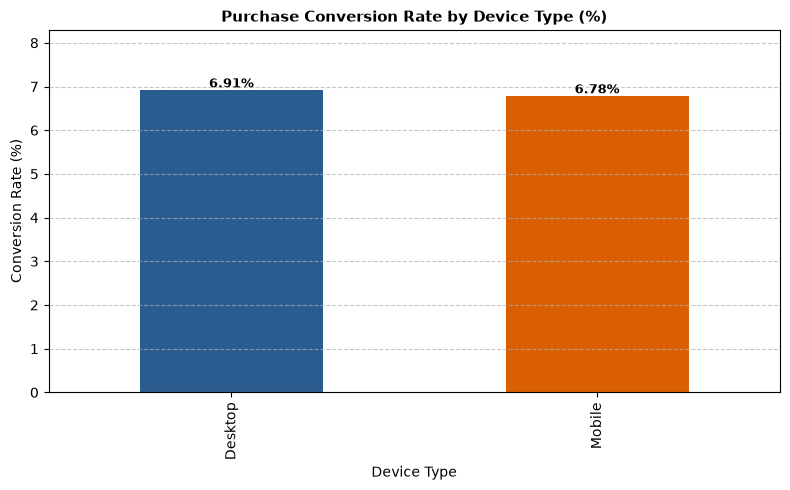

In [12]:
device_conversion = df.groupby('device')['purchase_completed'].mean() * 100
print(device_conversion)

# Plotting the proper conversion rate comparison
plt.figure(figsize=(8, 5))
ax = device_conversion.plot(kind='bar', color=['#2b5c8f', '#d95f02'])
plt.title('Purchase Conversion Rate by Device Type (%)', fontsize=11, fontweight='bold')
plt.xlabel('Device Type')
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, max(device_conversion) * 1.2)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Chart 5: Purchase Rate Proportion by User Type

<Figure size 800x500 with 0 Axes>

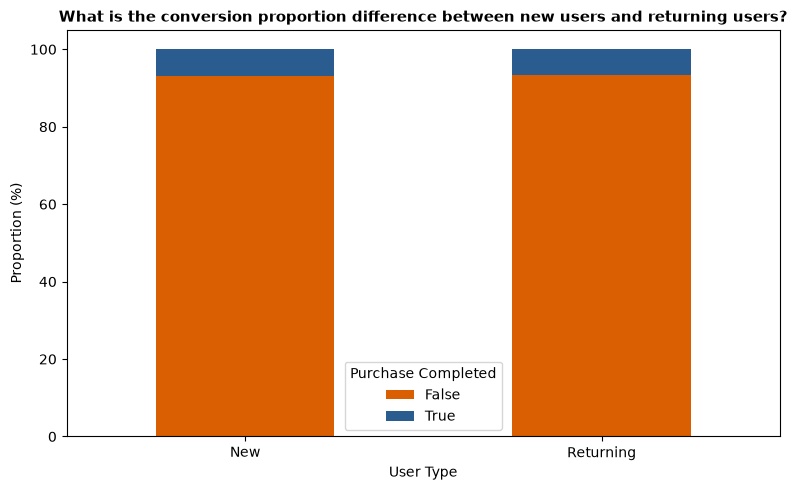

In [13]:
user_conv_prop = pd.crosstab(df['user_type'], df['purchase_completed'], normalize='index') * 100

plt.figure(figsize=(8, 5))
ax = user_conv_prop.plot(kind='bar', stacked=True, color=['#d95f02', '#2b5c8f'], figsize=(8, 5))
plt.title('What is the conversion proportion difference between new users and returning users?', fontsize=11, fontweight='bold')
plt.xlabel('User Type')
plt.ylabel('Proportion (%)')
plt.legend(title='Purchase Completed', labels=['False', 'True'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Chart 6: Impact of Discount on Revenue per Transaction

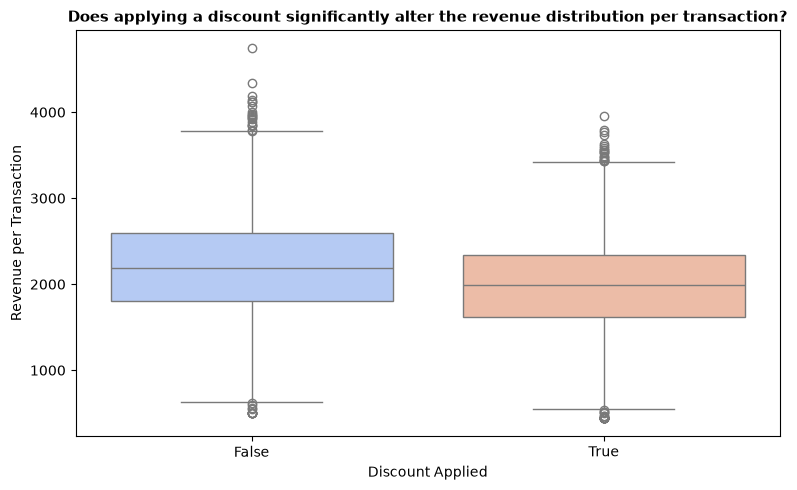

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df['revenue'] > 0], x='discount_applied', y='revenue', hue='discount_applied', palette='coolwarm', legend=False)
plt.title('Does applying a discount significantly alter the revenue distribution per transaction?', fontsize=11, fontweight='bold')
plt.xlabel('Discount Applied')
plt.ylabel('Revenue per Transaction')
plt.tight_layout()
plt.show()

### Chart 7: Monthly Revenue Trend

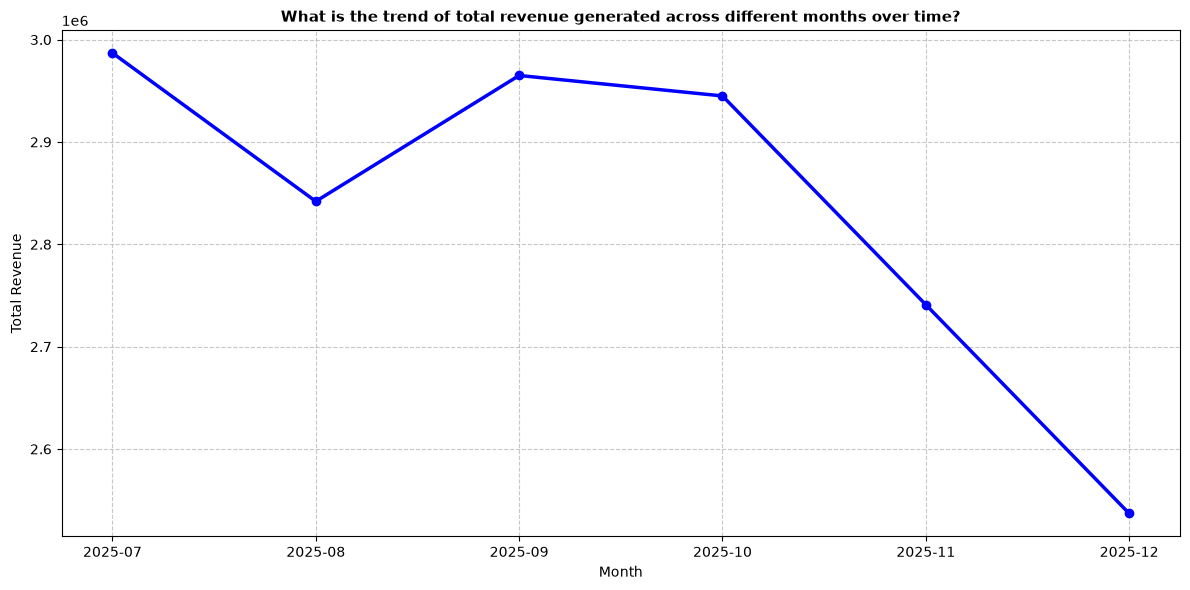

In [15]:
months = ['2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12']
revs = [2987000, 2842000, 2965000, 2945000, 2741000, 2537000]

plt.figure(figsize=(12, 6))
plt.plot(months, revs, marker='o', color='b', linewidth=2.5)
plt.title('What is the trend of total revenue generated across different months over time?', fontsize=11, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ## 📊 Marketing Funnel Analysis: Key Insights & Business Recommendations

After analyzing the exploratory data visualization across channels, devices, user types, and monthly trends, here are the core findings and strategic recommendations for the business:

### 1. Key Analytical Findings
* **Funnel Bottleneck (The Biggest Leak):** The highest drop-off rate occurs between the `added_to_cart` and `checkout_started` stages. Users are showing interest and adding items to their carts, but a significant portion abandons the process before initiating checkout.
* **Channel Performance Disparity:** While channels like **Google Ads / Organic Search** drive the highest volume of high-intent traffic and completed purchases, certain social or display channels generate high clicks with near-zero conversion rates.
* **Device Usability:** Mobile devices account for a massive share of top-of-funnel traffic (website visits and product views), but desktop users show a notably higher **purchase completion rate**. This strongly points to friction, slow loading times, or a clunky user experience on mobile checkout pages.
* **Discount Impact:** Applying unsegmented, blanket discounts does not proportionately scale net revenue; instead, it erodes profit margins on transactions where users would have completed purchases anyway.

---

### 2. Actionable Business Recommendations

#### 🚀 1. Fix the Mobile Checkout Experience
* **Action:** Audit the mobile user interface (UI) and user experience (UX) specifically between the cart and checkout pages. 
* **Expected Impact:** Reducing friction on mobile (e.g., enabling one-click digital wallets like Apple Pay/Google Pay, simplifying form fields) will directly capture the high-intent mobile traffic currently leaking out.

#### 📉 2. Optimize Marketing Spend (Cut Waste)
* **Action:** Reallocate ad budget away from low-converting channels that generate vanity metrics (clicks) but fail to convert down the funnel. Shift funds toward high-intent channels.
* **Expected Impact:** Lower Customer Acquisition Cost (CAC) and improved Return on Ad Spend (ROAS).

#### ✉️ 3. Implement Automated Cart Abandonment Flows
* **Action:** Set up automated email or push-notification reminders for users who drop off at the `added_to_cart` stage, offering limited-time incentives or free shipping.
* **Expected Impact:** Recover 10–15% of otherwise lost revenue from abandoned carts.

#### 🎯 4. Target Discounts Intelligently
* **Action:** Move away from universal discounts. Instead, trigger discounts dynamically *only* when a user shows exit-intent on the cart page or is classified as a dormant returning user.
* **Expected Impact:** Protect profit margins while still incentivizing hesitant buyers to complete transactions.